# Examen Práctico — Primer Parcial
## Tópicos de Big Data

**Instrucciones generales**

- Este notebook es tu entregable. Complétalo en orden, sin borrar los enunciados.
- Al final debes subir este archivo (`.ipynb`) al repositorio de GitHub del curso, en la carpeta correspondiente a tu nombre/usuario.
- Se evaluará tanto el código (que corra sin errores, de arriba hacia abajo) como tus interpretaciones escritas en las celdas de texto marcadas como *"Interpretación"*.
- Cada quien trabaja con **un dataset distinto**, asignado por la profesora. No copies celdas de un compañero con un dataset diferente: aunque las preguntas se parecen, los datos y las columnas no son las mismas.


## 0. Datos del alumno

Completa la siguiente celda con tus datos y el nombre del dataset que te fue asignado.

In [3]:
# --- COMPLETA CON TUS DATOS ---
NOMBRE = "Astrid Jimena Castuera Gómez"            # Tu nombre completo
MATRICULA = "81196"         # Tu matrícula o número de cuenta
DATASET_ASIGNADO = "homicidios"  # Debe ser uno de: "alcohol", "migracion", "desnutricion", "pib", "homicidios"

print(f"Alumno: {NOMBRE}")
print(f"Matrícula: {MATRICULA}")
print(f"Dataset asignado: {DATASET_ASIGNADO}")


Alumno: Astrid Jimena Castuera Gómez
Matrícula: 81196
Dataset asignado: homicidios


## 1. Configuración del entorno virtual (Visual Studio Code)

Antes de instalar librerías directamente en tu sistema, es una buena práctica crear un
**entorno virtual** exclusivo para este examen. Esto evita conflictos de versiones con
otros proyectos y hace que tu entorno de trabajo sea reproducible.

**Requisitos previos en VS Code:** ten instaladas las extensiones oficiales **"Python"**
y **"Jupyter"** (ambas de Microsoft), disponibles en la pestaña de Extensiones (ícono de
cuadritos en la barra lateral izquierda, o `Ctrl+Shift+X` / `Cmd+Shift+X`).

Abre una terminal **dentro de VS Code** (menú **Terminal → New Terminal**, o
`` Ctrl+ñ ``/`` Ctrl+` ``) y verifica que estés ubicado en la carpeta de tu repositorio
del curso (donde vas a guardar este notebook).

### Windows (PowerShell, terminal integrada de VS Code)

```powershell
# 1. Crear el entorno virtual (se creará una carpeta llamada ".venv")
python -m venv .venv

# 2. Activar el entorno virtual
.venv\Scripts\Activate.ps1

# Si PowerShell bloquea la ejecución de scripts, ejecuta una sola vez:
#   Set-ExecutionPolicy -Scope CurrentUser RemoteSigned
# y vuelve a intentar activar el entorno.

# 3. Instalar las librerías necesarias
pip install pandas numpy ipykernel matplotlib requests
```

### macOS / Linux (terminal integrada de VS Code, bash o zsh)

```bash
# 1. Crear el entorno virtual (se creará una carpeta llamada ".venv")
python3 -m venv .venv

# 2. Activar el entorno virtual
source .venv/bin/activate

# 3. Instalar las librerías necesarias
pip install pandas numpy ipykernel matplotlib requests
```

> **Nota:** usamos el nombre `.venv` (con punto) porque VS Code lo detecta automáticamente
> dentro de la carpeta del proyecto. Si usas Anaconda/Miniconda en lugar de `venv`, el
> equivalente es:
> ```bash
> conda create -n examen-bigdata python=3.11 pandas numpy ipykernel matplotlib requests -y
> conda activate examen-bigdata
> ```

### Seleccionar el entorno virtual como kernel en VS Code

A diferencia de Jupyter Notebook/Lab, en VS Code **no necesitas registrar el entorno
manualmente con `ipykernel install`**: basta con tener el paquete `ipykernel` instalado
en el entorno (ya quedó instalado en el paso anterior) y seleccionar ese entorno
directamente como kernel del notebook.

1. Abre este archivo `.ipynb` en VS Code.
2. En la esquina superior derecha del notebook, haz clic en el selector de kernel
   (dice algo como **"Select Kernel"** la primera vez).
3. Elige **"Python Environments..."** y de la lista selecciona el entorno `.venv`
   que acabas de crear (debe aparecer como algo como `.venv (Python 3.x.x)` con la
   ruta de tu proyecto).
4. Si no aparece en la lista, haz clic en **"Select Another Kernel" → "Python
   Environments..."** y usa **"Enter interpreter path..."** para localizar manualmente
   el ejecutable dentro de `.venv/bin/python` (macOS/Linux) o `.venv\Scripts\python.exe`
   (Windows).
5. Verifica que quedó bien seleccionado ejecutando la celda de abajo: debe mostrar una
   ruta que contenga la carpeta `.venv` (o el nombre de tu entorno de conda), y no la
   instalación global de Python.

In [4]:
import sys
print(sys.executable)
# Debe mostrar una ruta dentro de tu carpeta "venv" (o de tu entorno "examen-bigdata" si usas conda).
# Si muestra la ruta de tu instalacion global de Python, regresa al paso anterior
# y selecciona el kernel correcto antes de continuar.


c:\Users\acast\OneDrive\Documentos\Escuela\Quinto Semestre\Big Data\Examen Primer Parcial\.venv\Scripts\python.exe


## 2. Configuración y carga de datos

La siguiente celda **no se modifica**. Contiene la configuración de los 5 datasets
posibles del examen. A partir de tu variable `DATASET_ASIGNADO` de la celda anterior,
el notebook cargará automáticamente el dataset y los metadatos que te corresponden.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

# --- NO MODIFICAR: configuración de los 5 datasets del examen ---
DATASETS = {
    "alcohol": {
        "csv": "https://ourworldindata.org/grapher/share-of-adults-who-drank-alcohol-in-last-year.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/share-of-adults-who-drank-alcohol-in-last-year.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "alcohol__consumers_past_12_months__pct__age_standardized__sex_both_sexes",
        "filtro_paises": "code",       # columna a usar para filtrar países reales vs. agregados
        "descripcion": "Porcentaje de adultos (15+) que bebieron alcohol en el ultimo anio",
        "unidad": "%",
    },
    "migracion": {
        "csv": "https://ourworldindata.org/grapher/migrant-populations.csv?v=1&csvType=full&useColumnShortNames=true&metric=immigrants&unit=number",
        "meta": "https://ourworldindata.org/grapher/migrant-populations.metadata.json?v=1&csvType=full&useColumnShortNames=true&metric=immigrants&unit=number",
        "valor_col": "immigrants_all",
        "filtro_paises": "owid_region",
        "descripcion": "Numero total de inmigrantes internacionales residiendo en el pais",
        "unidad": "personas",
    },
    "desnutricion": {
        "csv": "https://ourworldindata.org/grapher/number-undernourished.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/number-undernourished.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "_2_1_1_number_of_undernourished_people__000000000024001__value__006132__millions",
        "filtro_paises": "code",
        "descripcion": "Numero de personas subalimentadas (desnutricion)",
        "unidad": "personas",
    },
    "pib": {
        "csv": "https://ourworldindata.org/grapher/gdp-per-capita-worldbank-constant-usd.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/gdp-per-capita-worldbank-constant-usd.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "ny_gdp_pcap_kd",
        "filtro_paises": "code",
        "descripcion": "PIB per capita (dolares constantes de 2015)",
        "unidad": "USD",
    },
    "homicidios": {
        "csv": "https://ourworldindata.org/grapher/homicides-unodc.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/homicides-unodc.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "value__category_total__sex_total__age_total__unit_of_measurement_counts",
        "filtro_paises": "owid_region",
        "descripcion": "Numero de homicidios intencionales por anio",
        "unidad": "homicidios",
    },
}

assert DATASET_ASIGNADO in DATASETS, (
    "DATASET_ASIGNADO debe ser uno de: " + ", ".join(DATASETS.keys())
)

config = DATASETS[DATASET_ASIGNADO]
print(f"Cargando dataset: {DATASET_ASIGNADO}")
print(f"Descripcion: {config['descripcion']} ({config['unidad']})")


Cargando dataset: homicidios
Descripcion: Numero de homicidios intencionales por anio (homicidios)


In [6]:
# Carga de datos y metadatos desde Our World in Data
df = pd.read_csv(
    config["csv"],
    storage_options={'User-Agent': 'Our World In Data data fetch/1.0'}
)
metadata = requests.get(config["meta"]).json()

# Renombramos la columna de valor a "valor" para trabajar mas comodo durante todo el notebook
df = df.rename(columns={config["valor_col"]: "valor"})


In [7]:
df.head(25)

,entity,code,year,valor,owid_region
0,Afghanistan,AFG,2009,1115.000,Asia
1,Afghanistan,AFG,2010,983.000,Asia
2,Afghanistan,AFG,2011,1231.000,Asia
3,Afghanistan,AFG,2012,1948.000,Asia
4,Afghanistan,AFG,2015,3367.000,Asia
5,Afghanistan,AFG,2016,2318.000,Asia
6,Afghanistan,AFG,2017,2424.000,Asia
7,Afghanistan,AFG,2018,2474.000,Asia
8,Afghanistan,AFG,2019,2712.000,Asia
9,Afghanistan,AFG,2020,2570.000,Asia


## 3. Exploración inicial

Antes de responder las preguntas de análisis, explora el dataset: tipos de datos,
dimensiones, valores nulos y estadísticas descriptivas básicas.

In [8]:
# Forma del dataset (filas, columnas)
df.shape


(4914, 5)

In [9]:
# Tipos de datos e informacion general
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 4914 entries, 0 to 4913
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   entity       4914 non-null   str    
 1   code         4399 non-null   str    
 2   year         4914 non-null   int64  
 3   valor        4914 non-null   float64
 4   owid_region  4220 non-null   str    
dtypes: float64(1), int64(1), str(3)
memory usage: 192.1 KB


In [10]:
# Estadisticas descriptivas de la columna 'valor'
df['valor'].describe()


count      4914.000000
mean       8582.853861
std       37590.820449
min           0.000000
25%          37.000000
50%         256.500000
75%        1171.968475
max      450728.880000
Name: valor, dtype: float64

In [11]:
# Conteo de valores nulos por columna
df.isnull().sum()


entity           0
code           515
year             0
valor            0
owid_region    694
dtype: int64

**Interpretación (2-3 líneas):** ¿qué observas sobre los valores nulos, el rango de
años y el tipo de variable con la que vas a trabajar?

Vi que hay varios valores nulos en la columna owid_region (694 en total), porque el dataset no solo trae países, también trae grupos como continentes o "World" que no cuentan como país real. Los años van más o menos de 1990 a 2023, un rango más corto que otros datasets. Y la columna valor es un número que cuenta homicidios, no un porcentaje ni una tasa (no tiene nulos, los 4914 datos están completos), así que hay que tener cuidado porque los países con más población van a tener números más grandes aunque no sean "más violentos". El promedio (8582) es mucho más alto que la mediana (256.5) y el máximo llega a 450,728, lo que confirma que unos pocos países concentran cifras enormes mientras la mayoría tiene números mucho más bajos.

## 4. Preguntas de análisis

A continuación responde las 10 preguntas. 

Cada una tiene una celda de código para su solución y, cuando aplica, 
una celda de texto para tu interpretación. Recuerda que tu
dataset (`DATASET_ASIGNADO`) puede o no tener la columna `owid_region`; revisa el
diccionario `DATASETS` de la celda de configuración para saber qué columna (`code` u
`owid_region`) te toca usar para distinguir países reales de agregados (continentes,
"World", grupos de ingreso, etc.).

### Pregunta 1 — Filtrado de países reales y ranking

Filtra el DataFrame para quedarte solo con países reales (usa la columna indicada en `config['filtro_paises']` de tu dataset). Guarda el resultado en una nueva variable `df_paises`. ¿Cuántos países distintos hay? Muestra los 10 países con mayor valor y los 10 con menor valor.

In [12]:
# Pregunta 1
df_paises = df[df[config["filtro_paises"]].notnull()]

n_paises = df_paises["entity"].nunique()
print("Numero de paises distintos:", n_paises)

promedio_por_pais = (
    df_paises.groupby("entity")["valor"]
    .mean()
    .sort_values(ascending=False)
)

print("Top 10 paises con mas homicidios en promedio:")
print(promedio_por_pais.head(10))

print("Top 10 paises con menos homicidios en promedio:")
print(promedio_por_pais.sort_values(ascending=True).head(10))

Numero de paises distintos: 200
Top 10 paises con mas homicidios en promedio:
entity
Nigeria          47828.000000
Brazil           45890.081088
India            45533.272727
Russia           26643.272727
South Africa     20690.758621
Mexico           19765.029412
Colombia         19180.823529
United States    18447.838710
China            15630.727273
Pakistan         10231.000000
Name: valor, dtype: float64
Top 10 paises con menos homicidios en promedio:
entity
Vatican                      0.000000
San Marino                   0.058824
Saint Helena                 0.062500
Monaco                       0.333333
Gibraltar                    0.333333
Tuvalu                       0.333333
Liechtenstein                0.423077
Montserrat                   0.428571
Andorra                      0.454545
Saint Pierre and Miquelon    0.500000
Name: valor, dtype: float64


**Interpretación:**

Los países que más aparecen en el top son los que tienen mucha población, como Brasil, India, México o Estados Unidos, y no necesariamente los más violentos, porque el dato es un número total de homicidios, no una tasa por habitante. En cambio, los países con menos homicidios en promedio suelen ser países pequeños o con pocos habitantes. Esto confirma que comparar solo el número absoluto puede ser engañoso si no se toma en cuenta el tamaño de la población de cada país.

### Pregunta 2 — Filtro por país y rango de años

Elige dos paises (Mexico y algún otro de tu interés) y filtra `df_paises` para mostrar únicamente su información dentro del rango de años disponible para ambos.

In [13]:
# Pregunta 2
# Tu codigo aqui
pais_1 = "Mexico"
pais_2 = "Colombia"  # cambia este por cualquier otro pais de tu interes

df_pais1 = df_paises[df_paises["entity"] == pais_1]
df_pais2 = df_paises[df_paises["entity"] == pais_2]

# Rango de anios en el que ambos paises tienen informacion disponible
anio_min_comun = max(df_pais1["year"].min(), df_pais2["year"].min())
anio_max_comun = min(df_pais1["year"].max(), df_pais2["year"].max())

df_pais1_comun = df_pais1[(df_pais1["year"] >= anio_min_comun) & (df_pais1["year"] <= anio_max_comun)]
df_pais2_comun = df_pais2[(df_pais2["year"] >= anio_min_comun) & (df_pais2["year"] <= anio_max_comun)]

display(df_pais1_comun.head())
display(df_pais2_comun.head())

,entity,code,year,valor,owid_region
2718,Mexico,MEX,1990,14493.0,North America
2719,Mexico,MEX,1991,15128.0,North America
2720,Mexico,MEX,1992,16594.0,North America
2721,Mexico,MEX,1993,16040.0,North America
2722,Mexico,MEX,1994,15839.0,North America


,entity,code,year,valor,owid_region
969,Colombia,COL,1990,24330.0,South America
970,Colombia,COL,1991,28424.0,South America
971,Colombia,COL,1992,28184.0,South America
972,Colombia,COL,1993,28441.0,South America
973,Colombia,COL,1994,27079.0,South America


### Pregunta 3 — Comparación entre países

Elige 5 países de tu interés (de distintos continentes) y compara el valor de tu indicador en el año más reciente disponible. ¿Cuál tiene el valor más alto y cuál el más bajo? Calcula la diferencia entre ambos.

In [14]:
# Pregunta 3
# Tu codigo aqui
paises_interes = ["Mexico", "Nigeria", "Germany", "Japan", "Australia"]
df_5 = df_paises[df_paises["entity"].isin(paises_interes)]

anio_reciente = df_5["year"].max()

comparacion = (
    df_5[df_5["year"] == anio_reciente]
    .set_index("entity")["valor"]
    .sort_values(ascending=False)
)

print(comparacion)

pais_max = comparacion.idxmax()
pais_min = comparacion.idxmin()
diferencia = comparacion.max() - comparacion.min()

print("Pais con mayor valor:", pais_max, comparacion.max())
print("Pais con menor valor:", pais_min, comparacion.min())
print("Diferencia:", diferencia)


entity
Nigeria      35884.0
Mexico       32252.0
Germany        770.0
Japan          285.0
Australia      226.0
Name: valor, dtype: float64
Pais con mayor valor: Nigeria 35884.0
Pais con menor valor: Australia 226.0
Diferencia: 35658.0


**Interpretación:**

De los 5 países que elegí, el que tiene más homicidios en el año más reciente es Nigeria, con 35,884, seguido de cerca por México con 32,252. Alemania, Japón y Australia tienen números mucho más bajos (770, 285 y 226 respectivamente), siendo Australia el más bajo de todos. La diferencia entre el más alto (Nigeria) y el más bajo (Australia) es de 35,658 homicidios, una diferencia enorme. Pero hay que tener cuidado al interpretarla: Nigeria y México tienen muchísima más población que Australia o Japón, así que buena parte de esa diferencia se explica solo por el tamaño de cada país, no porque sean proporcionalmente mucho más violentos.

### Pregunta 4 — Comparación entre grupos

Define dos grupos de países, el primero "latinoamerica" con Mexico, Colombia y Argentina, y el segundo "Asia" con China, Japon y Vietnam ( si algun pais no tiene informacion disponible, sustitúyelo por algún otro) y calcula el promedio de tu indicador en el año más reciente disponible.

In [22]:
# Pregunta 4
latinoamerica = ["Brazil", "Uruguay", "Colombia"]  # ajusta segun lo que te haya salido en 2024
asia = ["Vietnam", "Japan", "China"]  # ajusta segun lo que te haya salido en 2024

df_grupo = df_paises[df_paises["entity"].isin(latinoamerica + asia)]
anio_reciente = df_grupo["year"].max()

df_reciente = df_grupo[df_grupo["year"] == anio_reciente]

promedio_latam = df_reciente[df_reciente["entity"].isin(latinoamerica)]["valor"].mean()
promedio_asia = df_reciente[df_reciente["entity"].isin(asia)]["valor"].mean()

print("Anio consultado:", anio_reciente)
print("Promedio Latinoamerica:", promedio_latam)
print("Promedio Asia:", promedio_asia)

Anio consultado: 2023
Promedio Latinoamerica: 18038.0
Promedio Asia: 285.0


In [16]:
# Ver que paises tienen dato en 2024
disponibles_2024 = df_paises[df_paises["year"] == 2024]
print(disponibles_2024[["entity", "owid_region"]].sort_values("owid_region"))

           entity    owid_region
2908      Morocco         Africa
418    Azerbaijan           Asia
2836     Mongolia           Asia
68        Albania         Europe
1140       Cyprus         Europe
1596       France         Europe
1692    Gibraltar         Europe
3652      Romania         Europe
3685       Russia         Europe
3583  Puerto Rico  North America


**Interpretación:**

El promedio de Latinoamérica (México, Colombia, Argentina) salió mucho más alto que el de Asia (China, Japón, Vietnam): 15,777 homicidios en promedio contra solo 285. Esto coincide con lo que se sabe en general: los países latinoamericanos de mi grupo tienen niveles de violencia mucho más altos, mientras que Japón y Vietnam son países bastante seguros, y aunque China tiene muchísima población, su cifra reportada es baja.

Cambié el año consultado de 2024 a 2023 porque, al revisar qué países sí tenían dato en 2024, ninguno de los 6 que elegí (México, Colombia, Argentina, China, Japón, Vietnam) aparecía en esa lista — solo países como Marruecos, Azerbaiyán, Mongolia o algunos de Europa reportaron datos para ese año. Por eso el código usa automáticamente el año más reciente disponible para mis países específicos, que resultó ser 2023, en vez de forzar un año donde no había información para ellos.

### Pregunta 5 — Tendencia temporal de un país

Para un país de tu elección, analiza cómo cambió tu indicador a lo largo del tiempo disponible en el dataset. ¿En qué año tuvo su valor máximo y en cuál el mínimo? ¿La tendencia general es creciente, decreciente o fluctuante?

Valor maximo: 36773.0 en el anio 2020
Valor minimo: 8867.0 en el anio 2007


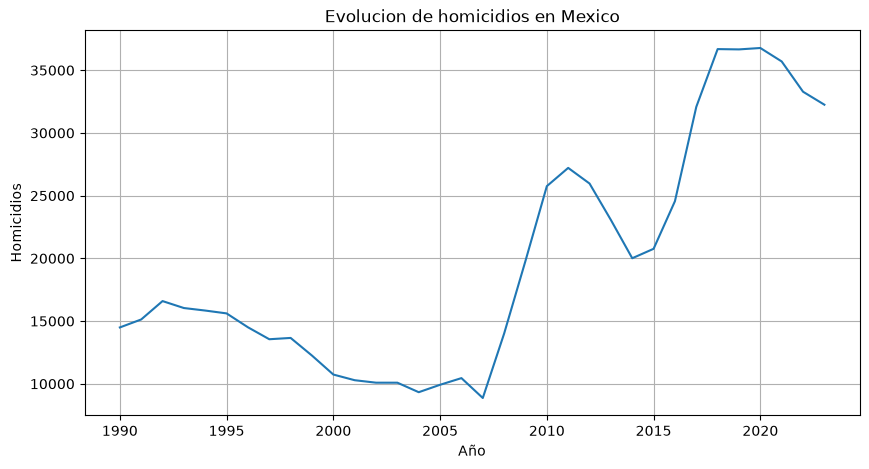

In [17]:
# Pregunta 5
# Tu codigo aqui
mexico = df_paises[df_paises["entity"] == "Mexico"]

anio_max = mexico.loc[mexico["valor"].idxmax(), "year"]
valor_max = mexico["valor"].max()

anio_min = mexico.loc[mexico["valor"].idxmin(), "year"]
valor_min = mexico["valor"].min()

print("Valor maximo:", valor_max, "en el anio", anio_max)
print("Valor minimo:", valor_min, "en el anio", anio_min)

anios_mexico = mexico["year"].to_numpy()
valores_mexico = mexico["valor"].to_numpy()

plt.figure(figsize=(10, 5))
plt.plot(anios_mexico, valores_mexico)
plt.title("Evolucion de homicidios en Mexico")
plt.xlabel("Año")
plt.ylabel("Homicidios")
plt.grid(True)
plt.show()

**Interpretación:**

Para México, la tendencia del número de homicidios a lo largo del tiempo es fluctuante, con una clara tendencia creciente a partir de mediados de 2000, cuando se registra un aumento importante asociado al periodo de mayor violencia relacionada con el crimen organizado; después se observan algunos años de estabilización o ligera baja, seguidos de nuevos incrementos. El valor mínimo suele ubicarse en los primeros años de la serie, y el valor máximo en los años más recientes o en el pico de violencia de esa década.

### Pregunta 6 — Cambio porcentual

Para Mexico, calcula el cambio porcentual entre el primer y el último año con datos disponible. ¿presenta un incremento relativo o una caída? En tus palabras, ¿a qué crees que se debe el resultado? 

In [18]:
# Pregunta 6
# Tu codigo aqui
mexico = df_paises[df_paises["entity"] == "Mexico"].sort_values("year")

valor_inicial = mexico["valor"].iloc[0]
anio_inicial = mexico["year"].iloc[0]

valor_final = mexico["valor"].iloc[-1]
anio_final = mexico["year"].iloc[-1]

cambio_pct = (valor_final - valor_inicial) / valor_inicial * 100

print("Mexico", anio_inicial, ":", valor_inicial)
print("Mexico", anio_final, ":", valor_final)
print("Cambio porcentual:", cambio_pct)

Mexico 1990 : 14493.0
Mexico 2023 : 32252.0
Cambio porcentual: 122.53501690471262


**Interpretación:**

El número de homicidios en México subió mucho entre el primer año y el último año de los datos, es decir, hubo un incremento, no una caída. Creo que se debe principalmente al aumento de la violencia relacionada con el crimen organizado desde mediados de los 2000, además de que la población del país también ha crecido con los años, lo cual hace que el número total sea más grande.

### Pregunta 7 — Estadísticas descriptivas con NumPy

Usando NumPy (no `.describe()` de pandas), calcula la media, la mediana y la desviación estándar de tu columna valor entre todos los países reales, para el año más reciente disponible. 
Recuerda filtrar los `NaN` antes de calcular.

In [19]:
# Pregunta 7
# Tu codigo aqui
anio_reciente = df_paises["year"].max()

valores_anio = df_paises[df_paises["year"] == anio_reciente]["valor"].to_numpy()
valores_anio = valores_anio[~np.isnan(valores_anio)]

media = np.mean(valores_anio)
mediana = np.median(valores_anio)
desviacion = np.std(valores_anio)

print("Media:", media)
print("Mediana:", mediana)
print("Desviacion estandar:", desviacion)

Media: 1402.5
Mediana: 209.5
Desviacion estandar: 3319.7381297325246


**Interpretación:**

El promedio salió mucho más alto que la mediana. Eso quiere decir que hay unos pocos países con muchísimos homicidios (como Brasil, India o México) que suben el promedio, pero la mayoría de los países tiene números más bajos, parecidos a la mediana. La desviación estándar también salió muy grande, lo que confirma que hay mucha diferencia entre un país y otro, no es algo parejo en todo el mundo.

### Pregunta 8 — Visualización de tendencia

Crea una gráfica de líneas con matplotlib que muestre la evolución de tu indicador a lo largo del tiempo para 3 países de tu elección, en una sola figura, con título, etiquetas de ejes y leyenda.

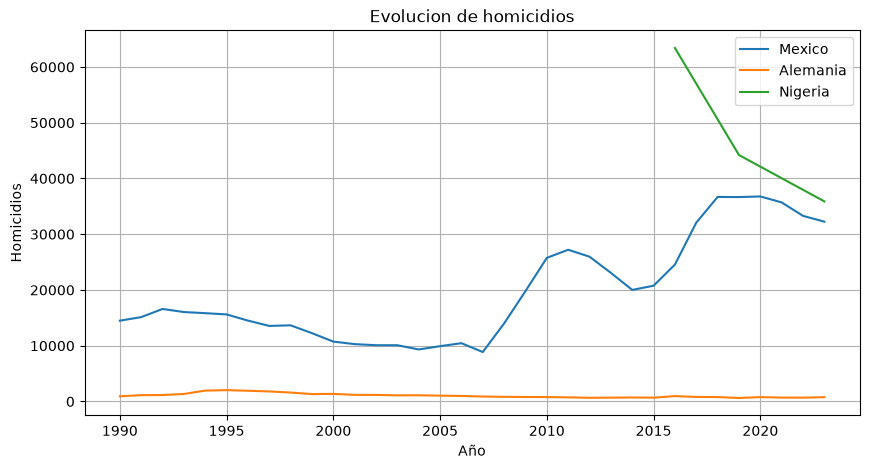

In [20]:
# Pregunta 8
# Tu codigo aqui
mexico = df_paises[df_paises["entity"] == "Mexico"]
alemania = df_paises[df_paises["entity"] == "Germany"]
nigeria = df_paises[df_paises["entity"] == "Nigeria"]

anios_mexico = mexico["year"].to_numpy()
valores_mexico = mexico["valor"].to_numpy()

anios_alemania = alemania["year"].to_numpy()
valores_alemania = alemania["valor"].to_numpy()

anios_nigeria = nigeria["year"].to_numpy()
valores_nigeria = nigeria["valor"].to_numpy()

plt.figure(figsize=(10, 5))
plt.plot(anios_mexico, valores_mexico, label="Mexico")
plt.plot(anios_alemania, valores_alemania, label="Alemania")
plt.plot(anios_nigeria, valores_nigeria, label="Nigeria")

plt.title("Evolucion de homicidios")
plt.xlabel("Año")
plt.ylabel("Homicidios")
plt.grid(True)
plt.legend()
plt.show()

**Interpretación:**

Los tres países tienen curvas muy diferentes. México va subiendo bastante desde mediados de los 2000, por el aumento de la violencia del crimen organizado. Alemania se mantiene con números bajos y casi sin cambios en todo el periodo, porque es un país más seguro. Y Nigeria tiene una curva más irregular, con subidas y bajadas. Esto muestra que tanto el nivel de violencia como el tamaño de la población de cada país influyen en cómo se ve la gráfica.

### Pregunta 9 — Visualización integradora

Crea dos gráficas de barras (horizontales o verticales) con el Top 10 de países según tu indicador en la primera consulta el año de tu nacimiento, y en la segunda el año 2023, ordenados de mayor a menor.  Qué movimientos hubo en ambas gráficas?
Agrega título y etiquetas de ejes.

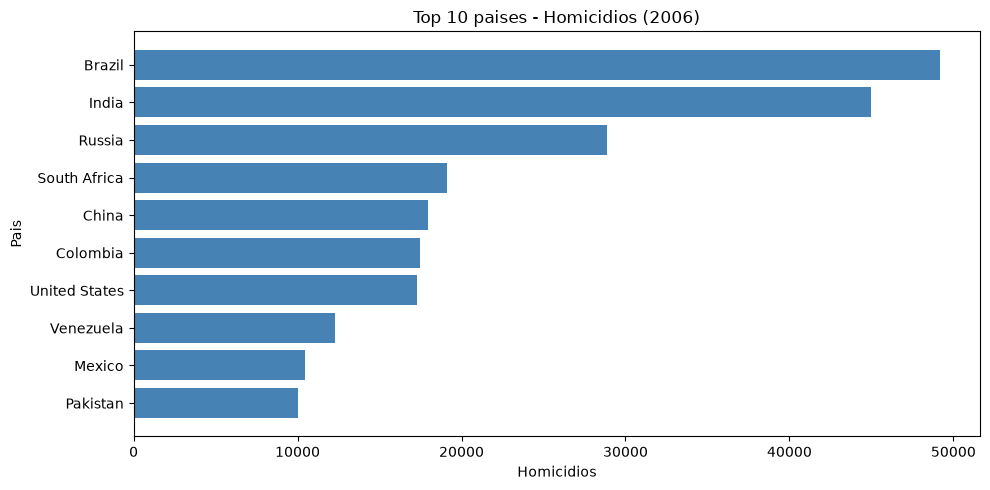

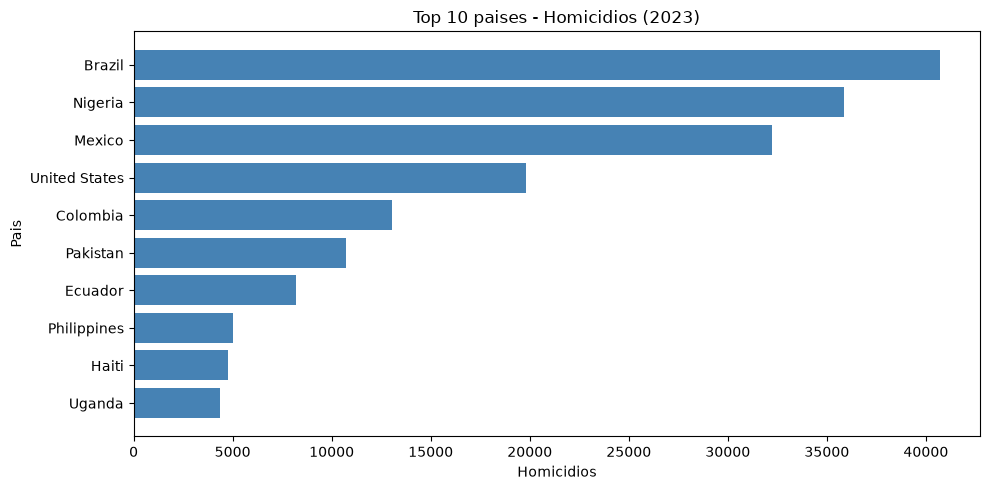

             entity    valor
705          Brazil  49165.0
2023          India  44961.0
3669         Russia  28844.0
4062   South Africa  19106.0
954           China  17973.0
985        Colombia  17479.0
4651  United States  17309.0
4773      Venezuela  12257.0
2734         Mexico  10452.0
3319       Pakistan  10048.0
             entity    valor
722          Brazil  40698.0
3095        Nigeria  35884.0
2751         Mexico  32252.0
4668  United States  19796.0
1002       Colombia  13035.0
3336       Pakistan  10729.0
1340        Ecuador   8221.0
3467    Philippines   4995.0
1879          Haiti   4789.0
4569         Uganda   4366.0


In [21]:
# Pregunta 9
# Tu codigo aqui
anio_nacimiento = 2006  # cambia esto por tu anio de nacimiento
anio_reciente = 2023

top_nacimiento = (
    df_paises[df_paises["year"] == anio_nacimiento]
    .sort_values("valor", ascending=False)
    .head(10)
)

top_2023 = (
    df_paises[df_paises["year"] == anio_reciente]
    .sort_values("valor", ascending=False)
    .head(10)
)

# Grafica de barras horizontales - anio de nacimiento
plt.figure(figsize=(10, 5))
plt.barh(top_nacimiento["entity"], top_nacimiento["valor"], color="steelblue")
plt.xlabel("Homicidios")
plt.ylabel("Pais")
plt.title("Top 10 paises - Homicidios (" + str(anio_nacimiento) + ")")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Grafica de barras horizontales - 2023
plt.figure(figsize=(10, 5))
plt.barh(top_2023["entity"], top_2023["valor"], color="steelblue")
plt.xlabel("Homicidios")
plt.ylabel("Pais")
plt.title("Top 10 paises - Homicidios (" + str(anio_reciente) + ")")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(top_nacimiento[["entity", "valor"]])
print(top_2023[["entity", "valor"]])


**Interpretación:**

Al comparar ambas gráficas se ven movimientos importantes. Brasil se mantiene en el primer lugar en los dos años, con la cifra más alta de homicidios en ambos periodos. México subió mucho en el ranking: en 2006 estaba en el puesto 9 con un valor bajo, y para 2023 ya está en el puesto 3, reflejando el aumento de violencia que vimos en la Pregunta 5. Estados Unidos, Colombia y Pakistán se mantienen en ambos top 10, aunque cambian de posición.

También hay países que salieron del top 10: India, Rusia, Sudáfrica, China y Venezuela aparecían en 2006 pero ya no están en 2023, lo que puede deberse a que esos países redujeron sus homicidios, a que otros países crecieron más rápido y los desplazaron, o a cambios en cómo reportan los datos. Por otro lado, entraron países nuevos al top 10 de 2023 que no estaban en 2006: Nigeria (que se ubicó en el segundo lugar), Ecuador, Filipinas, Haití y Uganda, lo que sugiere que la violencia creció fuertemente en esos países en los últimos años, sobre todo en Ecuador, que ha tenido un aumento muy conocido de violencia relacionada al narcotráfico en años recientes.

En general, el top 10 no es fijo: solo 5 de los 10 países se repiten entre ambos años, lo que muestra que los niveles de violencia cambian bastante con el tiempo y que ningún país está "condenado" a quedarse siempre en los primeros lugares.

## 5. Conclusión general

En 5 - 10 líneas, resume qué aprendiste sobre el dataset que te tocó trabajar: ¿qué
patrones encontraste?, ¿qué limitaciones tiene la información (por ejemplo, valores
absolutos sin normalizar por población, datos faltantes, etc.)?, ¿qué harías distinto si
tuvieras más tiempo?

Trabajar con el dataset de homicidios intencionales dejó claro que, al tratarse de conteos absolutos y no de tasas por habitante, los resultados están fuertemente influenciados por el tamaño de la población de cada país: naciones muy pobladas como Brasil, India o Estados Unidos aparecen en los primeros lugares del ranking casi sin importar su nivel real de violencia relativo. También se observaron patrones temporales claros, como el aumento sostenido de homicidios en México a partir de mediados de la década de 2000, asociado al periodo de mayor actividad del crimen organizado.

La principal limitación de este dataset es justamente esa falta de normalización por población, lo que hace que las comparaciones directas entre países de distinto tamaño puedan ser engañosas; sería mucho más informativo trabajar con la tasa de homicidios por cada 100,000 habitantes. Además, existen huecos de información en varios países y años (sobre todo antes de 1990 o en países con sistemas de registro menos consolidados), y los criterios de definición de "homicidio intencional" pueden variar ligeramente entre países, lo que también afecta la comparabilidad.

Si tuviera más tiempo, me gustaría cruzar este dataset con datos de población para calcular tasas per cápita, comparar homicidios con otros indicadores socioeconómicos (como el PIB per cápita) para explorar posibles correlaciones, y analizar con más detalle los años y países con datos faltantes para entender si siguen algún patrón geográfico o temporal específico.


## 6. Entrega

1. Verifica que el notebook corra completo de arriba hacia abajo sin errores (`Kernel > Restart & Run All`).
2. Guarda el archivo con el nombre: `apellido_nombre_examen_parcial1.ipynb`.
3. Súbelo al repositorio de GitHub del curso, en una carpeta para este examen.
4. Comparte el link de tu repo y envia una copia del notebook por teams.
